<a href="https://colab.research.google.com/github/VitAnCha/-/blob/main/%D0%98%D1%82%D0%BE%D0%B3%D0%BE%D0%B2%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%D0%90%D0%92%D0%A1_DAU_96.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Проект на тему:
### «Анализ оттока клиентов банка (поиск инсайтов, составление рекомендаций стейкхолдерам)».

Ануфриевой В.С.

Группа: DAU-96

2026 год.

# 1. Подключение библиотек

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
import random
import scipy.stats as stats
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu, shapiro, normaltest
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import roc_auc_score

# 2. Подключение источника данных и его описание


In [ ]:
df = pd.read_csv('Customer-Churn-Records.csv', index_col=0 )
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
RowNumber,,,,,,,,,,,,,,,,,
1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 1 to 10000
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerId          10000 non-null  int64  
 1   Surname             10000 non-null  object 
 2   CreditScore         10000 non-null  int64  
 3   Geography           10000 non-null  object 
 4   Gender              10000 non-null  object 
 5   Age                 10000 non-null  int64  
 6   Tenure              10000 non-null  int64  
 7   Balance             10000 non-null  float64
 8   NumOfProducts       10000 non-null  int64  
 9   HasCrCard           10000 non-null  int64  
 10  IsActiveMember      10000 non-null  int64  
 11  EstimatedSalary     10000 non-null  float64
 12  Exited              10000 non-null  int64  
 13  Complain            10000 non-null  int64  
 14  Satisfaction Score  10000 non-null  int64  
 15  Card Type           10000 non-null  object 
 16  Point Ear

*Описание полей:*
1. CustomerID (ID клиента) - int64.
2. Surname (Фамилия клиента) - object.
3. CreditScore (Кредитный рейтинг) - int64.
4. Geography (Страна) - object.
5. Gender (Пол клиента)- object.
6. Age (Возраст клиента) - int64.
7. Tenure (Количество лет сотрудничества)- int64.  
8. Balance (Баланс) - float64.
9. NumOfProducts (Количество услуг банка) - int64.  
10. HasCrCard (Наличие кредитной карты) - int64.  
11. IsActiveMember (Вовлеченнность клиента) - int64.  
12. EstimatedSalary (Оценочная зарплата) - float64.
13. Exited (Отток) - int64.  
14. Complain (Жалобы) - int64.  
15. Satisfaction Score (Уровень удовлетворенности) - int64.  
16. Card Type (Тип карты) - object.
17. Point Earned (Заработанные баллы) - int64.

Числовых полей - 13; категориальных полей - 4.

In [ ]:
df.describe()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned,Geography_enc,Gender_enc
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100,0.749500,0.545700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839,0.830433,0.497932
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000,0.000000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000,0.000000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000,0.000000,1.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000,2.000000,1.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000,2.000000,1.000000


# 3. Предобработка данных

### 3.1. Первичное исследование, работа с выбросами и аномалиями

In [ ]:
print(df.isnull().sum())

CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64


In [ ]:
df.duplicated().sum()

np.int64(0)

Вывод: пропущенные значения и дубликаты отсутсвуют.

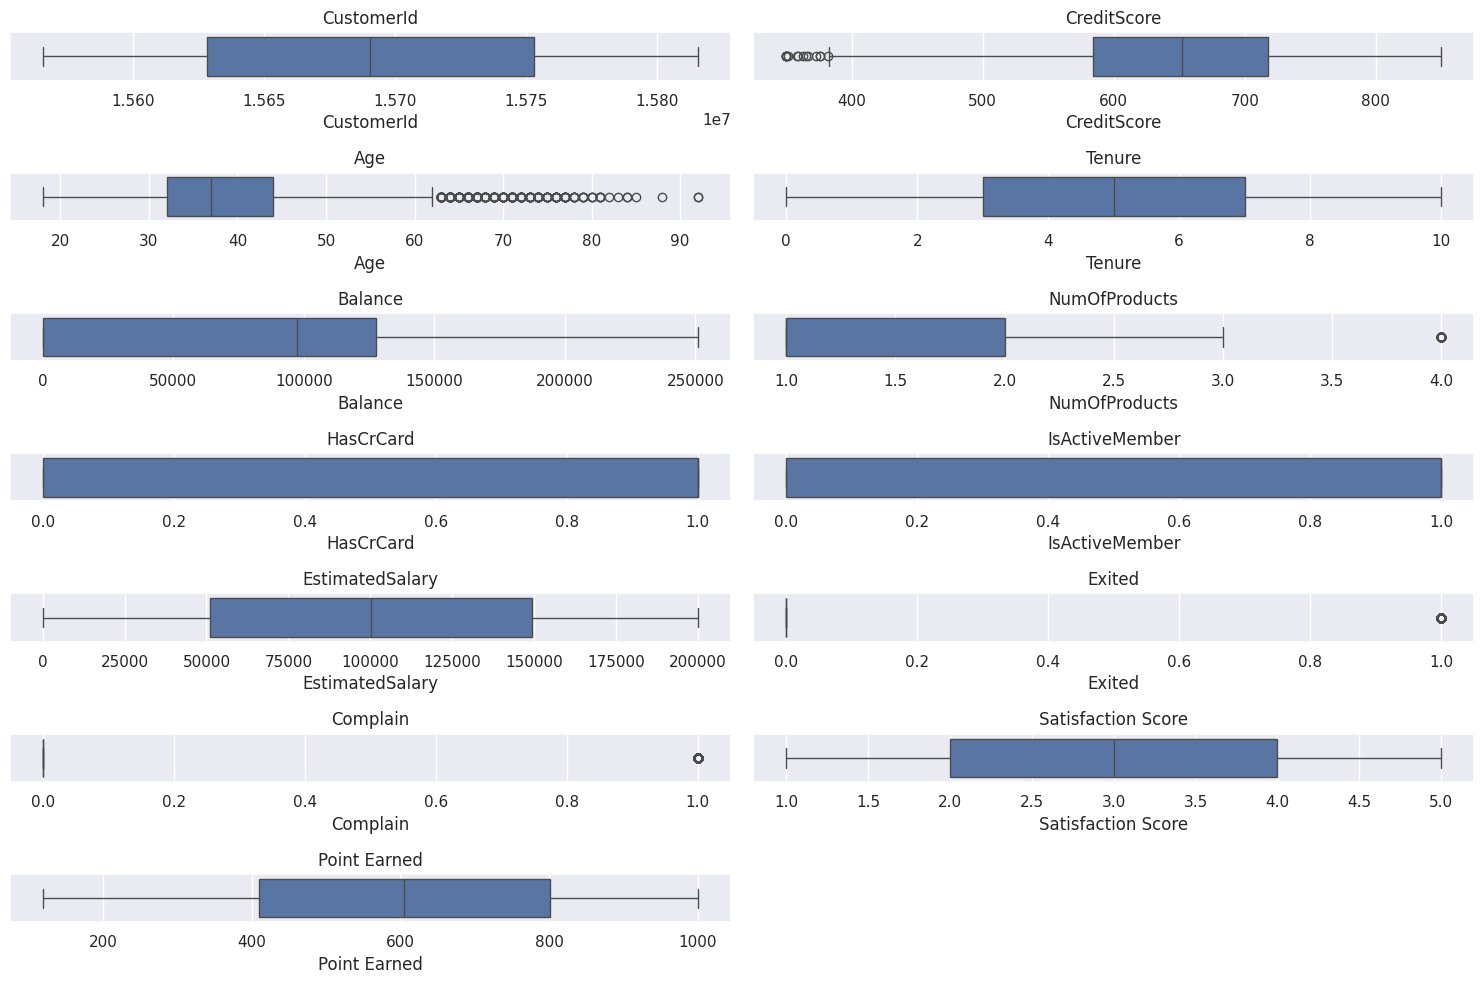

In [ ]:
#Визуальный анализ (Boxplot)
# Создаем список числовых столбцов
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Создаем Boxplot для каждого числового столбца
plt.figure(figsize=(15, 10))
for i, column in enumerate(numeric_columns):
    plt.subplot(len(numeric_columns) // 2 + 1, 2, i + 1)
    sns.boxplot(x=column, data=df)
    plt.title(column)

plt.tight_layout()
plt.show()

In [ ]:
# Удаляем идентификаторы и фамилии
columns_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df_clean = df.drop(columns=columns_to_drop, errors='ignore')

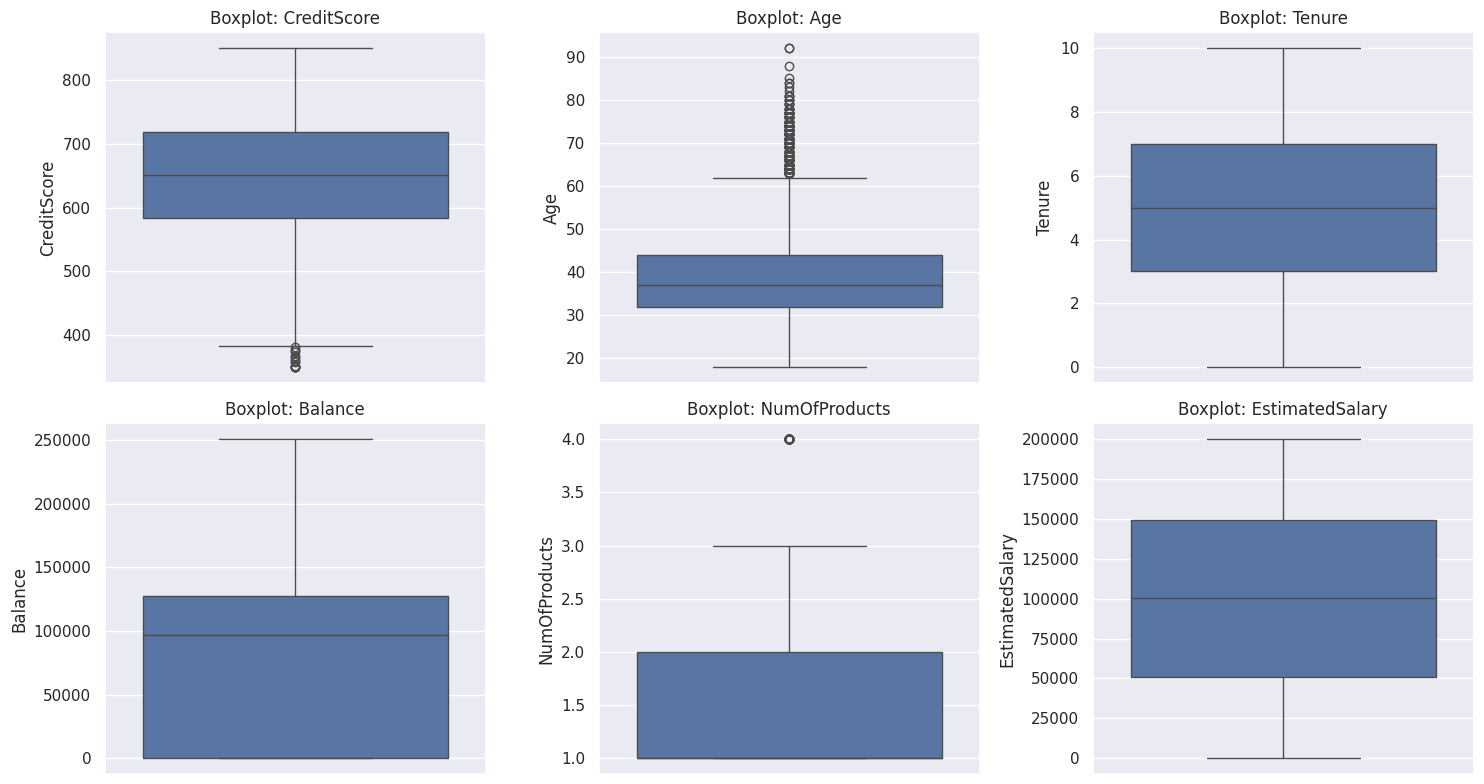

In [ ]:
#Анализ выбросов в числовых значениях
numeric_columns = ['CreditScore', 'Age', 'Tenure', 'Balance','NumOfProducts', 'EstimatedSalary']

plt.figure(figsize=(15,8))
for i, col in enumerate (numeric_columns, 1):
  plt.subplot (2, 3, i)
  sns.boxplot (y=df[col])
  plt.title (f'Boxplot: {col}')
plt.tight_layout ()
plt.show (
)

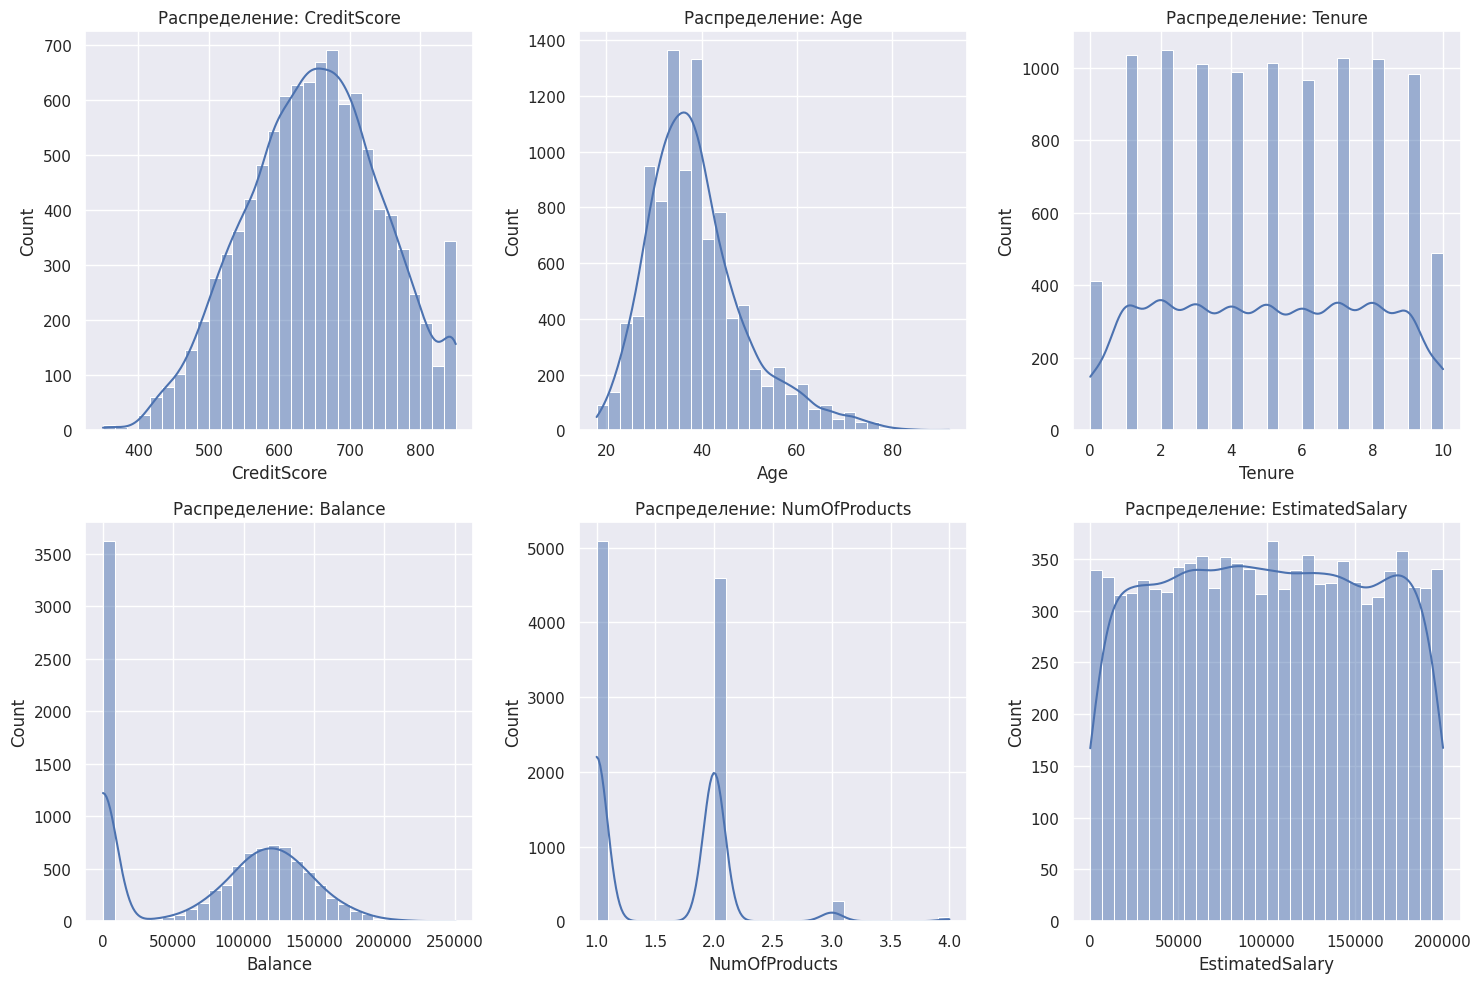

In [ ]:
#гистограммы с KDE
plt.figure (figsize=(15, 10))
for i, col in enumerate (numeric_columns, 1):
  plt.subplot (2, 3, i)
  sns.histplot(df[col], kde=True, bins=30)
  plt.title (f'Распределение: {col}')
plt.tight_layout ()
plt.show ()

In [ ]:
def find_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Поиск выбросов для каждого числового признака
outliers_summary = {}
for col in numeric_columns:
    outliers, lb, ub = find_outliers_iqr(df, col)
    outliers_summary[col] = {
        'count': len(outliers),
        'lower_bound': lb,
        'upper_bound': ub
    }
    print(f"{col}: найдено {len(outliers)} выбросов. Границы: [{lb:.2f}, {ub:.2f}]")

CreditScore: найдено 15 выбросов. Границы: [383.00, 919.00]
Age: найдено 359 выбросов. Границы: [14.00, 62.00]
Tenure: найдено 0 выбросов. Границы: [-3.00, 13.00]
Balance: найдено 0 выбросов. Границы: [-191466.36, 319110.60]
NumOfProducts: найдено 60 выбросов. Границы: [-0.50, 3.50]
EstimatedSalary: найдено 0 выбросов. Границы: [-96577.10, 296967.45]


Детальный анализ выбросов по ключевым признакам.

Выбросы в Age:
              Age      Exited
count  359.000000  359.000000
mean    69.270195    0.203343
std      5.237059    0.403047
min     63.000000    0.000000
25%     65.000000    0.000000
50%     68.000000    0.000000
75%     72.000000    0.000000
max     92.000000    1.000000


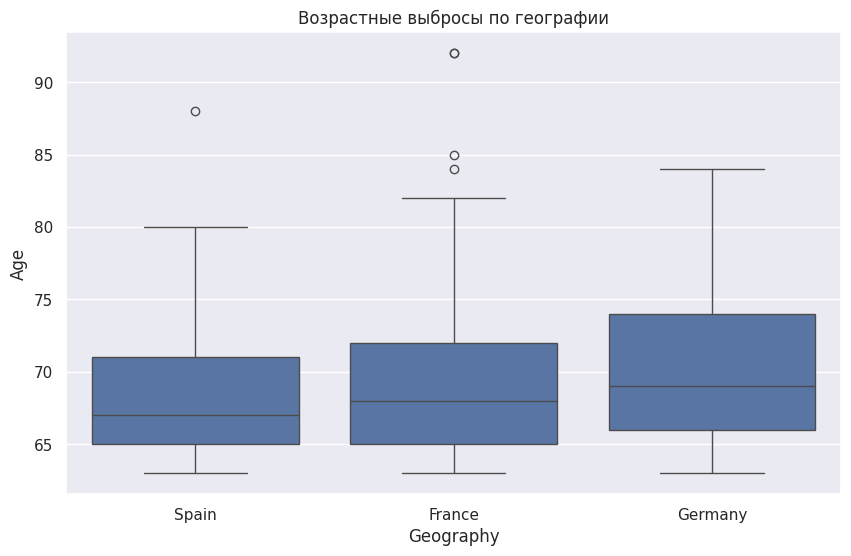

In [ ]:
age_outliers, _, _ = find_outliers_iqr(df, 'Age')
print("Выбросы в Age:")
print(age_outliers[['Age', 'Exited']].describe())

# Возрастные выбросы по географии
if 'Geography' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Geography', y='Age', data=age_outliers)
    plt.title('Возрастные выбросы по географии')
    plt.show()

In [ ]:
# Создаём сводную таблицу по выбросам
outliers_report = pd.DataFrame({
    'Признак': numeric_columns,
    'Всего записей': [len(df)] * len(numeric_columns),
    'Выбросов (IQR)': [outliers_summary[col]['count'] for col in numeric_columns],
    '% выбросов': [round(outliers_summary[col]['count'] / len(df) * 100, 2) for col in numeric_columns]
})

print("\nСводная таблица выбросов:")
print(outliers_report)


Сводная таблица выбросов:
           Признак  Всего записей  Выбросов (IQR)  % выбросов
0      CreditScore          10000              15        0.15
1              Age          10000             359        3.59
2           Tenure          10000               0        0.00
3          Balance          10000               0        0.00
4    NumOfProducts          10000              60        0.60
5  EstimatedSalary          10000               0        0.00


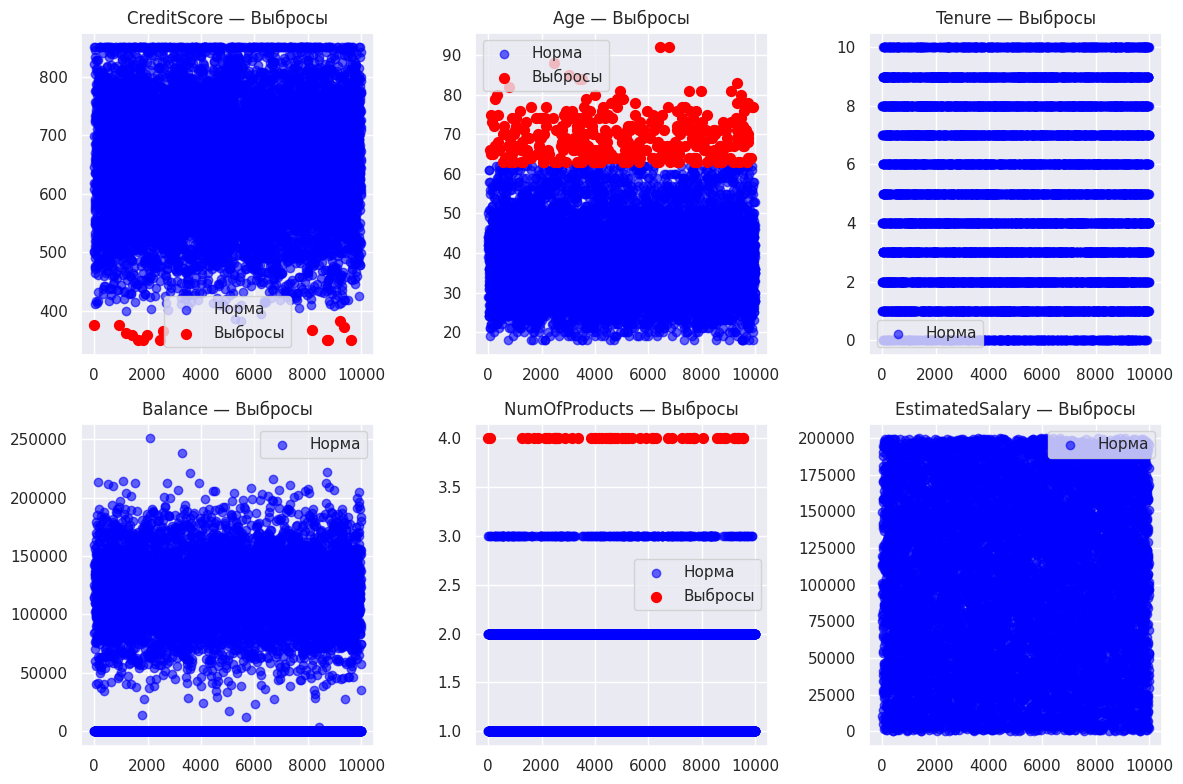

In [ ]:
# Визуализация распределения выбросов по всем признакам
plt.figure(figsize=(12, 8))

for i, col in enumerate(numeric_columns, 1):
    plt.subplot(2, 3, i)
    # Все данные
    plt.scatter(df.index, df[col], alpha=0.6, label='Норма', color='blue')
    # Выбросы по IQR
    outliers, _, _ = find_outliers_iqr(df, col)
    if not outliers.empty:
        plt.scatter(outliers.index, outliers[col], color='red', label='Выбросы', s=50)
    plt.title(f'{col} — Выбросы')
    plt.legend()

plt.tight_layout()
plt.show()

#Краткий итог

*Результаты анализа:*

---



CreditScore: 15 выбросов, могут быть реальными данными; незначительно повлияют на анализ

Age: 359 возрастных выбросов, большинство на пожилых клиентах;

Balance: нулевые балансы — необязательно выбросы (могут быть неактивные счета);

*Рекомендации по обработке:*

---



CreditScore — оставить как есть (реальные данные).

Age — проверить и исправить ошибки. Выбросы представляют пожилых клиентов, поэтому имеют ценность для анализа.



### 3.2. Преобразование категориальных данных в числовой формат.



In [ ]:
# Создаем копию для кодирования
df_encoded = df.copy()
label_encoders = {}

for column in ['Geography', 'Gender', 'Card Type']:
    le = LabelEncoder()
    df_encoded[f'{column}_encoded'] = le.fit_transform(df_encoded[column])
    label_encoders[column] = le
    print(f"{column} mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Geography mapping: {'France': np.int64(0), 'Germany': np.int64(1), 'Spain': np.int64(2)}
Gender mapping: {'Female': np.int64(0), 'Male': np.int64(1)}
Card Type mapping: {'DIAMOND': np.int64(0), 'GOLD': np.int64(1), 'PLATINUM': np.int64(2), 'SILVER': np.int64(3)}


# 4. Аналитика для стейкхолдеров


### 4.1. Формирование сводов данных, вычисление метрик

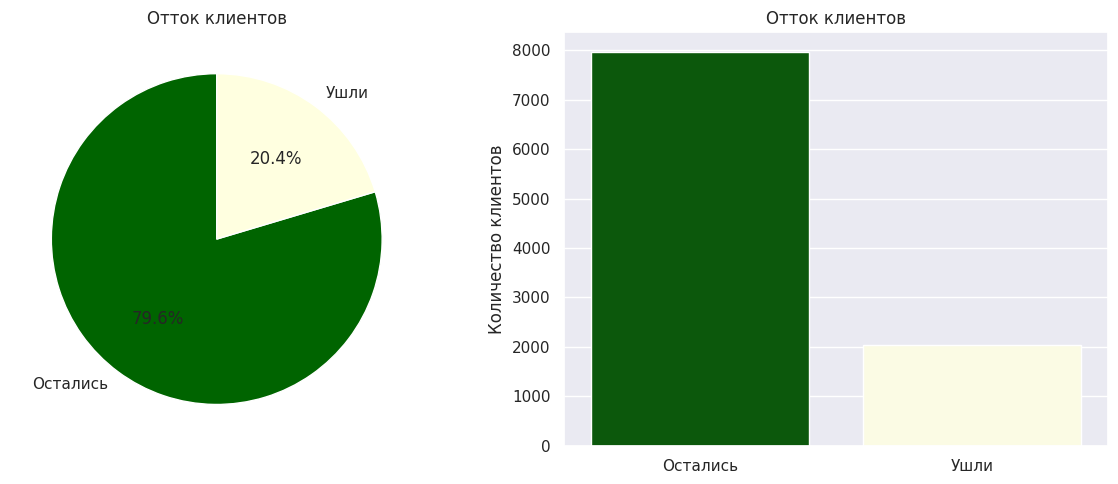

In [ ]:
# Основные метрики оттока

churn_rate = df['Exited'].mean()
churn_count = df['Exited'].sum()
total_customers = len(df)

# Визуализация общего оттока
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Круговая диаграмма
churn_counts = df['Exited'].value_counts()
ax1.pie(churn_counts.values, labels=['Остались', 'Ушли'], autopct='%1.1f%%', startangle=90, colors=['darkgreen', 'lightyellow'])
ax1.set_title('Отток клиентов')

# Столбчатая диаграмма
categories = ['Остались', 'Ушли']
sns.barplot(x=categories, y=churn_counts.values, ax=ax2, hue=categories,
            palette=['darkgreen', 'lightyellow'],
            legend=False)
ax2.set_title('Отток клиентов')
ax2.set_ylabel('Количество клиентов')

plt.tight_layout()
plt.show()


Вывод: уровень оттока клиентов составляет 20.4%, практически каждый 5 клиент.

### 4.2. Анализ оттока по демографическому признаку

In [ ]:
# Создадим возрастные группы
df['Age_cutting'] = pd.cut(df['Age'], bins=[0, 30, 40, 50, 60, 100],
                       labels=['18-29', '30-40', '41-50', '51-60', '60+'])

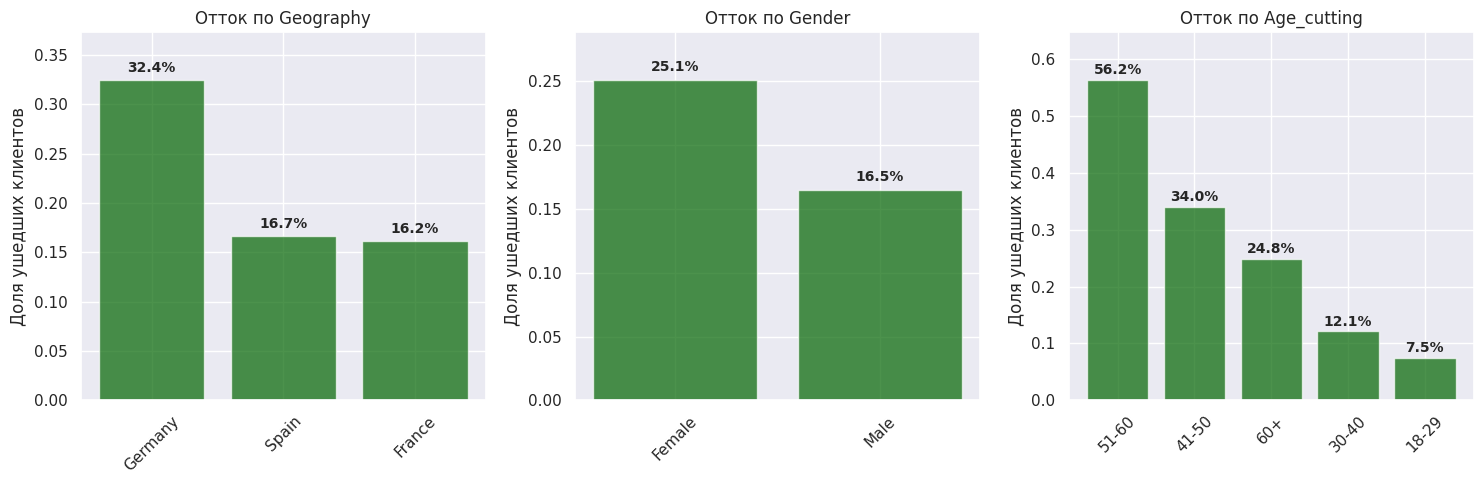

In [ ]:
demographic_factors = ['Geography', 'Gender', 'Age_cutting']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, factor in enumerate(demographic_factors):
    churn_data = df.groupby(factor, observed=False)['Exited'].mean().sort_values(ascending=False)

    bars = axes[i].bar(range(len(churn_data)), churn_data.values, color='darkgreen', alpha=0.7)
    axes[i].set_title(f'Отток по {factor}')
    axes[i].set_xticks(range(len(churn_data)))
    axes[i].set_xticklabels(churn_data.index, rotation=45)
    axes[i].set_ylabel('Доля ушедших клиентов')
    axes[i].set_ylim(0, churn_data.max() * 1.15)

    # Добавляем значения на столбцы
    for bar, v in zip(bars, churn_data.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{v:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**Выводы:**
1. По географическому типу максимальный отток клиентов приходится на Германию - 32.4%, то есть каждый 3 клиент.
2. Если смотреть на пол клиентов, то женщины чаще уходят - 25.1%.
3. На графике возраста видно, что люди старше 50 лет уходят чаще, что составляет 56.2%. То есть более половины клиентов.

### 4.3. Анализ оттока вовлеченных клиентов

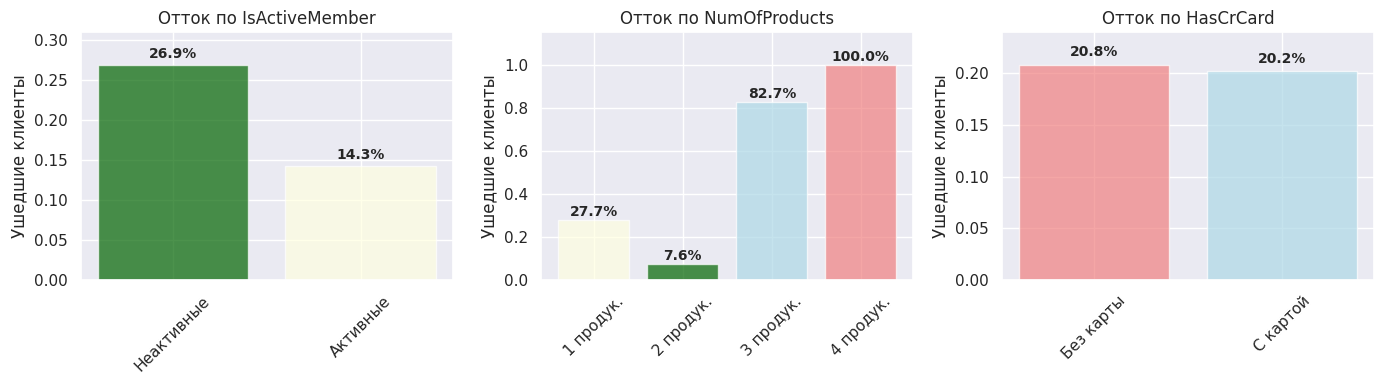

In [ ]:
active_clients = ['IsActiveMember', 'NumOfProducts', 'HasCrCard']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, factor in enumerate(active_clients):
    churn_data = df.groupby(factor)['Exited'].mean()

    if factor == 'IsActiveMember':
        labels = ['Неактивные', 'Активные']
        colors = ['darkgreen', 'lightyellow']
    elif factor == 'HasCrCard':
        labels = ['Без карты', 'С картой']
        colors = ['lightcoral', 'lightblue']
    else:
        labels = [f'{x} продук.' for x in churn_data.index]
        colors = ['lightyellow', 'darkgreen', 'lightblue', 'lightcoral'][:len(churn_data)]

    bars = axes[i].bar(labels, churn_data.values, color=colors, alpha=0.7)
    axes[i].set_title(f'Отток по {factor}')
    axes[i].set_ylabel('Ушедшие клиенты')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylim(0, churn_data.max() * 1.15)

    for bar, v in zip(bars, churn_data.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{v:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

Итог:
1. Неактивные клиенты чаще уходят - 26.9%.
2. Банк покидают клиенты с более 2 продуктами - от 82.7 до 100%. Также высокий показатель у клиентов с 1 продуктом - 27.7%.
3. Кредитная карта мало влияет на отток клиентов.

# 5.  Сегменты риска


In [ ]:
# Возрастные группы
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 30, 40, 50, 60, 120],
                        labels=['<30', '30-40', '40-50', '50-60', '60+'])
# Баланс: низкий/средний/высокий
bins = [-1, 50000, 200000, float('inf')]
labels = ['Low', 'Medium', 'High']

df['BalanceSegment'] = pd.cut(df['Balance'], bins=bins, labels=labels, right=True, include_lowest=True)

# Количество продуктов: мало/много
df['ProductsSegment'] = df['NumOfProducts'].apply(lambda x: '1-2' if x <= 2 else '3-4')

# Активность
df['ActiveSegment'] = df['IsActiveMember'].map({0: 'Inactive', 1: 'Active'})

In [ ]:
def churn_rate_by_segment(df, segment_col):
    return (df.groupby(segment_col)['Exited']
            .agg(['count', 'sum'])
            .assign(churn_rate=lambda x: x['sum'] / x['count'])
            .sort_values('churn_rate', ascending=False))
print("Отток по возрасту:")
print(churn_rate_by_segment(df, 'AgeGroup'))

print("\nОтток по балансу:")
print(churn_rate_by_segment(df, 'BalanceSegment'))

print("\nОтток по количеству продуктов:")
print(churn_rate_by_segment(df, 'ProductsSegment'))


Отток по возрасту:
          count  sum  churn_rate
AgeGroup                        
50-60       797  448    0.562108
40-50      2320  788    0.339655
60+         464  115    0.247845
30-40      4451  539    0.121096
<30        1968  148    0.075203

Отток по балансу:
                count   sum  churn_rate
BalanceSegment                         
High               34    19    0.558824
Medium           6274  1493    0.237966
Low              3692   526    0.142470

Отток по количеству продуктов:
                 count   sum  churn_rate
ProductsSegment                         
3-4                326   280    0.858896
1-2               9674  1758    0.181724


/tmp/ipykernel_3172/4021405876.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return (df.groupby(segment_col)['Exited']
/tmp/ipykernel_3172/4021405876.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return (df.groupby(segment_col)['Exited']


### 5.1 Визуализация сегментов риска
Barplot: доля оттока по сегментам

/tmp/ipykernel_3172/1441775837.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return (df.groupby(segment_col)['Exited']
/tmp/ipykernel_3172/1980298831.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_by_seg.index, y='churn_rate', data=churn_by_seg, palette='Reds')


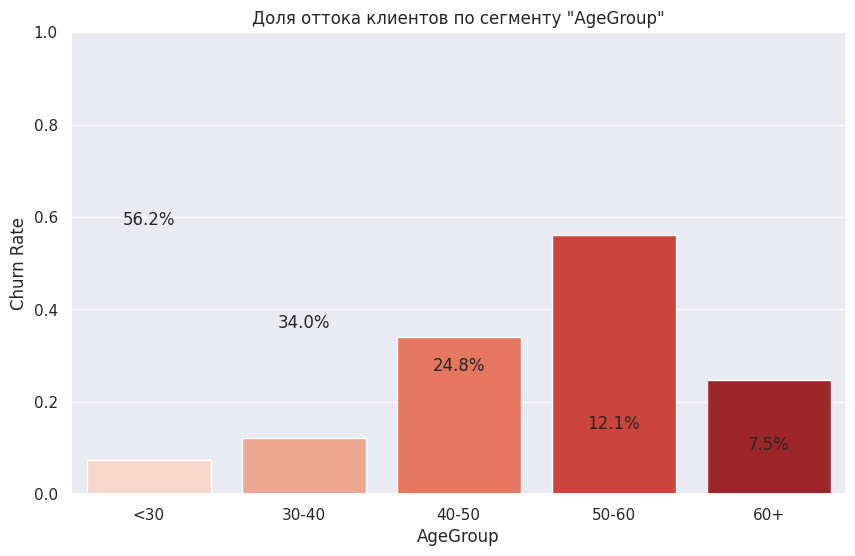

In [ ]:
seg_col = 'AgeGroup'

churn_by_seg = churn_rate_by_segment(df, seg_col)

plt.figure(figsize=(10, 6))
sns.barplot(x=churn_by_seg.index, y='churn_rate', data=churn_by_seg, palette='Reds')
plt.title(f'Доля оттока клиентов по сегменту "{seg_col}"')
plt.xlabel(seg_col)
plt.ylabel('Churn Rate')
plt.ylim(0, 1)
for i, v in enumerate(churn_by_seg['churn_rate']):
    plt.text(i, v + 0.02, f'{v:.1%}', ha='center')
plt.show()


/tmp/ipykernel_3172/1441775837.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return (df.groupby(segment_col)['Exited']
/tmp/ipykernel_3172/1588440915.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_by_seg.index, y='churn_rate', data=churn_by_seg, palette='Reds')


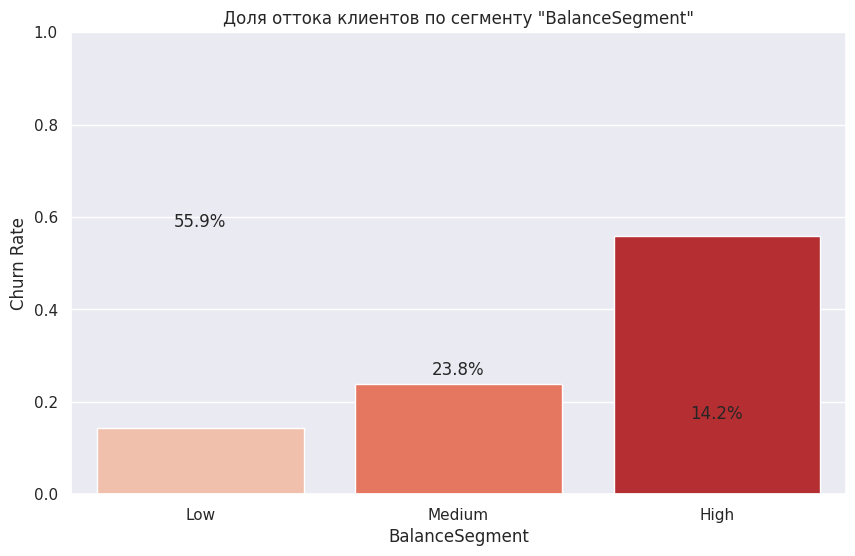

In [ ]:
seg_col = 'BalanceSegment'

churn_by_seg = churn_rate_by_segment(df, seg_col)

plt.figure(figsize=(10, 6))
sns.barplot(x=churn_by_seg.index, y='churn_rate', data=churn_by_seg, palette='Reds')
plt.title(f'Доля оттока клиентов по сегменту "{seg_col}"')
plt.xlabel(seg_col)
plt.ylabel('Churn Rate')
plt.ylim(0, 1)
for i, v in enumerate(churn_by_seg['churn_rate']):
    plt.text(i, v + 0.02, f'{v:.1%}', ha='center')
plt.show()


/tmp/ipykernel_3172/1629258727.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_by_seg.index, y='churn_rate', data=churn_by_seg, palette='Reds')


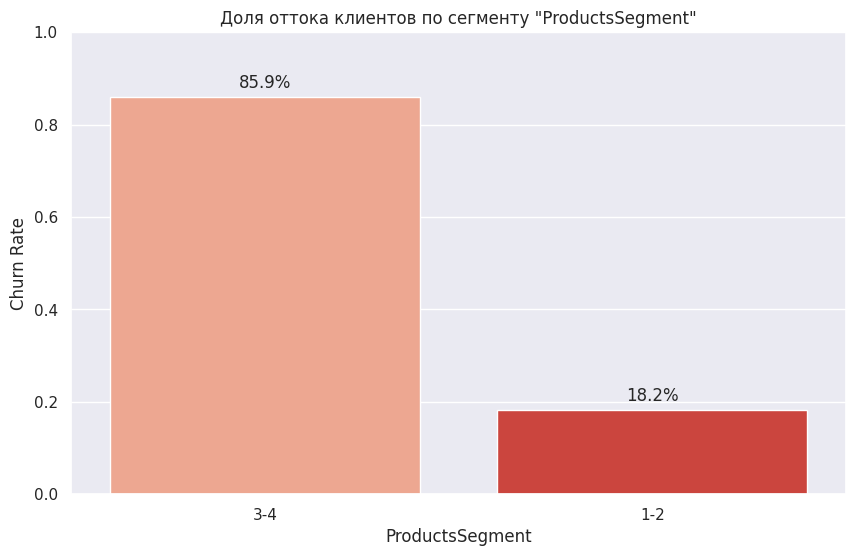

In [ ]:
seg_col = 'ProductsSegment'

churn_by_seg = churn_rate_by_segment(df, seg_col)

plt.figure(figsize=(10, 6))
sns.barplot(x=churn_by_seg.index, y='churn_rate', data=churn_by_seg, palette='Reds')
plt.title(f'Доля оттока клиентов по сегменту "{seg_col}"')
plt.xlabel(seg_col)
plt.ylabel('Churn Rate')
plt.ylim(0, 1)
for i, v in enumerate(churn_by_seg['churn_rate']):
    plt.text(i, v + 0.02, f'{v:.1%}', ha='center')
plt.show()

### 5.2. Тепловая карта (heatmap) для двух факторов




/tmp/ipykernel_3172/1522690538.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_churn = (df.pivot_table(index='AgeGroup', columns='ActiveSegment',


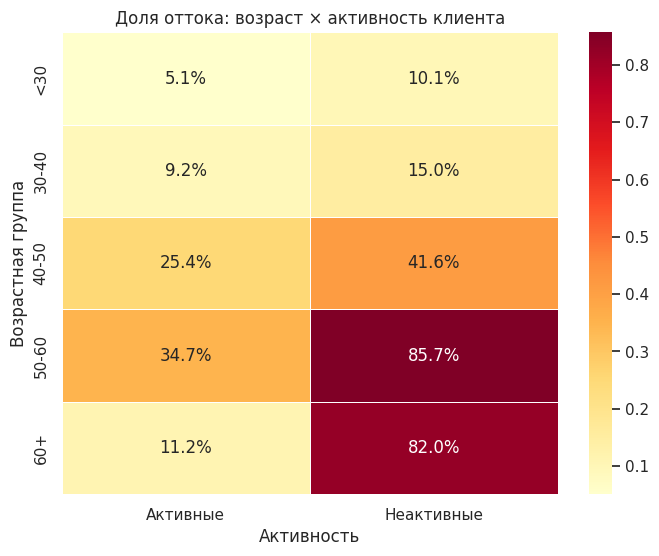

In [ ]:
pivot_churn = (df.pivot_table(index='AgeGroup', columns='ActiveSegment',
                              values='Exited', aggfunc='mean')
               .rename(columns={'Inactive': 'Неактивные', 'Active': 'Активные'}))

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_churn, annot=True, fmt='.1%', cmap='YlOrRd', linewidths=.5)
plt.title('Доля оттока: возраст × активность клиента')
plt.xlabel('Активность')
plt.ylabel('Возрастная группа')
plt.show()


### 5.3. Boxplot: распределение баланса у ушедших и оставшихся







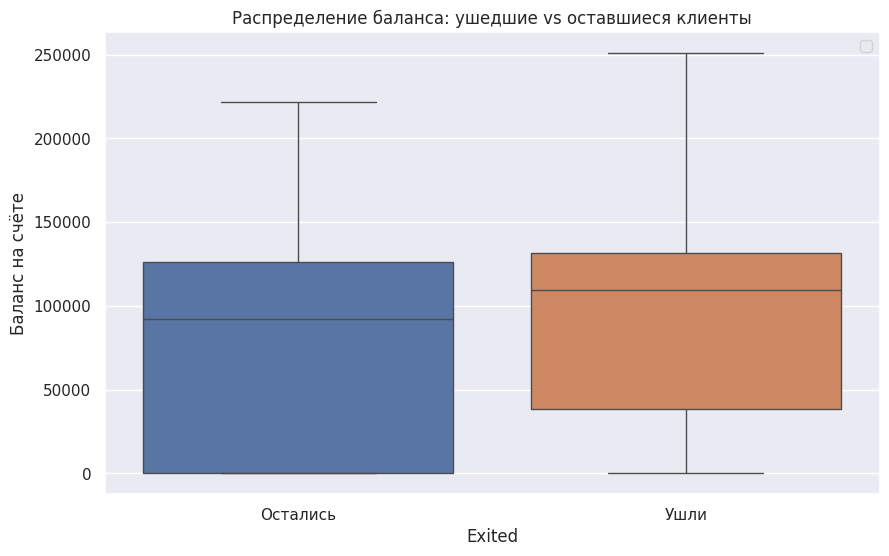

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Exited', y='Balance', hue='Exited')
plt.xticks([0, 1], ['Остались', 'Ушли'])
plt.title('Распределение баланса: ушедшие vs оставшиеся клиенты')
plt.ylabel('Баланс на счёте')
plt.legend([], [])
plt.show()


### 5.4. Комбинированный график: доля оттока + размер сегмента




/tmp/ipykernel_3172/1441775837.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return (df.groupby(segment_col)['Exited']
/tmp/ipykernel_3172/192821666.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_by_seg.index, y='churn_rate', data=churn_by_seg,


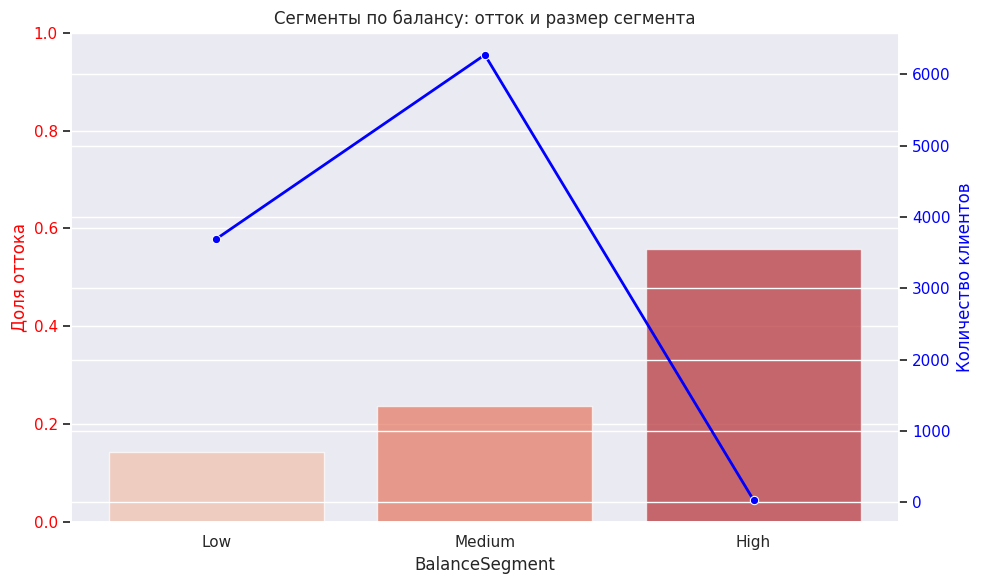

In [ ]:
seg_col = 'BalanceSegment'
churn_by_seg = churn_rate_by_segment(df, seg_col)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Столбцы: доля оттока
sns.barplot(x=churn_by_seg.index, y='churn_rate', data=churn_by_seg,
            palette='Reds', ax=ax1, alpha=0.7)
ax1.set_ylabel('Доля оттока', color='red')
ax1.tick_params(axis='y', labelcolor='red')
ax1.set_ylim(0, 1)

# Линия: размер сегмента (количество клиентов)
ax2 = ax1.twinx()
sns.lineplot(x=churn_by_seg.index, y='count', data=churn_by_seg,
             marker='o', color='blue', linewidth=2, ax=ax2)
ax2.set_ylabel('Количество клиентов', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title(f'Сегменты по балансу: отток и размер сегмента')
plt.tight_layout()
plt.show()


 ### 5.5. Выделение «сегментов риска»


In [ ]:
total_customers = len(df)
threshold_churn_high = 0.25
threshold_size_high = 0.05
threshold_churn_medium = 0.15
threshold_size_medium = 0.10

def assign_risk_level(row):
    churn = row['churn_rate']
    size_share = row['count'] / total_customers
    if churn > threshold_churn_high and size_share > threshold_size_high:
        return 'Высокий'
    elif (churn > threshold_churn_medium) or (size_share > threshold_size_medium):
        return 'Средний'
    else:
        return 'Низкий'

churn_by_seg = churn_by_seg.assign(risk_level=lambda x: x.apply(assign_risk_level, axis=1))
print(churn_by_seg)


                count   sum  churn_rate risk_level
BalanceSegment                                    
High               34    19    0.558824    Средний
Medium           6274  1493    0.237966    Средний
Low              3692   526    0.142470    Средний


# 6. Корреляционный анализ

In [ ]:
# Кодируем категориальные переменные для корреляции
df['Geography_enc'] = df['Geography'].map({'France': 0, 'Spain': 1, 'Germany': 2})
df['Gender_enc'] = df['Gender'].map({'Female': 0, 'Male': 1})

In [ ]:
# Выбираем только числовые колонки для корреляции (включая закодированные)
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
            'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
            'Geography_enc', 'Gender_enc', 'Exited']

df_num = df[num_cols].copy()

###Матрица корреляций Пирсона

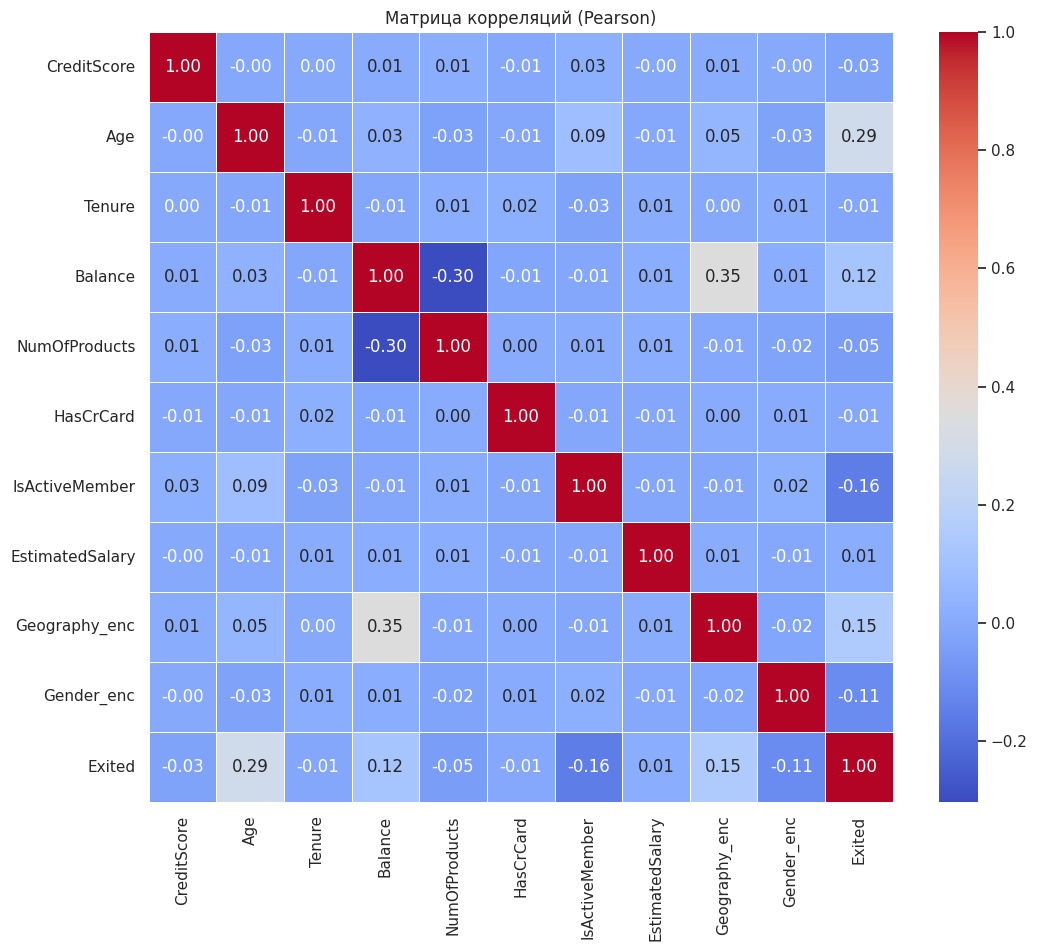

In [ ]:
corr_matrix = df_num.corr(method='pearson')

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=.5)
plt.title('Матрица корреляций (Pearson)')
plt.show()


In [ ]:
#топ-корреляции с оттоком
churn_corr = corr_matrix['Exited'].drop('Exited').sort_values(ascending=False)
print("Корреляция признаков с оттоком (по убыванию):")
print(churn_corr)


Корреляция признаков с оттоком (по убыванию):
Age                0.285296
Geography_enc      0.153518
Balance            0.118577
EstimatedSalary    0.012490
HasCrCard         -0.006976
Tenure            -0.013656
CreditScore       -0.026771
NumOfProducts     -0.047611
Gender_enc        -0.106267
IsActiveMember    -0.156356
Name: Exited, dtype: float64


Итог:
1. IsActiveMember - сильная отрицательная корреляция (неактивные клиенты уходят чаще). Это ожидаемый и полезный признак модели.

2. Age - часто положительная (средний возраст связан с более высоким оттоком). Чем старше клиент, тем выше вероятность оттока. Он может указывать на то, что пожилые люди чаще закрывают счета при смене жизненных обстоятельств или уходят к конкурентам.

3. Balance - может быть слабой или даже положительной (клиенты с очень высоким балансом иногда уходят). Это может быть признаком "премиального оттока": такие клиенты чувствительны к качеству сервиса и могут уходить к конкурентам с более выгодными ставками.

4. Geography - есть связь между регионом и оттоком. Вероятно, высока конкуренция или хуже качество обслуживания отделений.

###Визуализация корреляций с целевой переменной

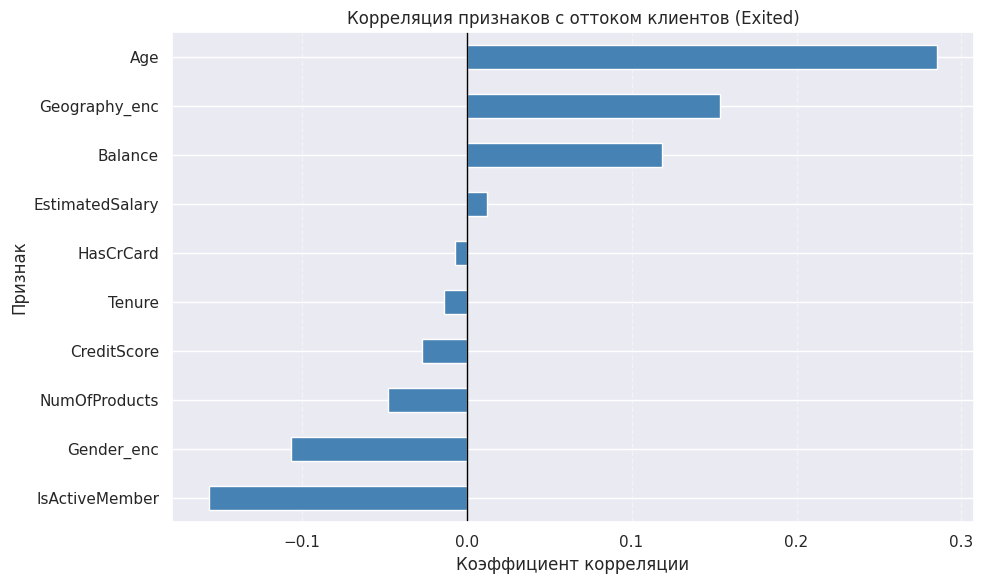

In [ ]:
plt.figure(figsize=(10, 6))
churn_corr.sort_values().plot(kind='barh', color='steelblue')
plt.axvline(0, color='black', linewidth=1)
plt.title('Корреляция признаков с оттоком клиентов (Exited)')
plt.xlabel('Коэффициент корреляции')
plt.ylabel('Признак')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


***Практические выводы:***

---



---



1. На основе анализа выявлено, что возраст клиента является наиболее значимым фактором, влияющим на отток. Клиенты старшего возраста демонстрируют более высокую склонность к уходу из банка.

2. Размер баланса на счете также показывает заметную положительную связь с оттоком, что свидетельствует о повышенном риске ухода клиентов с крупными остатками.

3. Баланс: иногда уходят клиенты с очень высоким балансом (они «дороги» банку и могут быть более чувствительны к условиям).

4. Количество продуктов: клиенты с 3–4 продуктами могут уходить из‑за «перегруза» или из‑за того, что банк не смог удержать их лояльность.



Ключевой вывод:
#####Банку следует сосредоточить внимание на программах удержания для клиентов старшего возраста и клиентов с высокими остатками на счетах, как наиболее подверженных риску оттока.


# 7. Проверка гипотез

***Гипотеза 1: Возраст ушедших и оставшихся клиентов различается.***

H₀: средний возраст ушедших и оставшихся одинаков.

H₁: средний возраст различается.

In [ ]:
age_churned = df[df['Exited'] == 1]['Age']
age_retained = df[df['Exited'] == 0]['Age']

t_stat, p_value = ttest_ind(age_churned, age_retained, equal_var=False)  # Welch’s t-test
print(f"T-тест для возраста: t={t_stat:.3f}, p-value={p_value:.4f}")

if p_value < 0.05:
    print("Отклоняем H₀: возраст ушедших статистически значимо отличается от оставшихся.")
else:
    print("Не удаётся отклонить H₀: нет значимых различий в возрасте.")


T-тест для возраста: t=30.420, p-value=0.0000
Отклоняем H₀: возраст ушедших статистически значимо отличается от оставшихся.


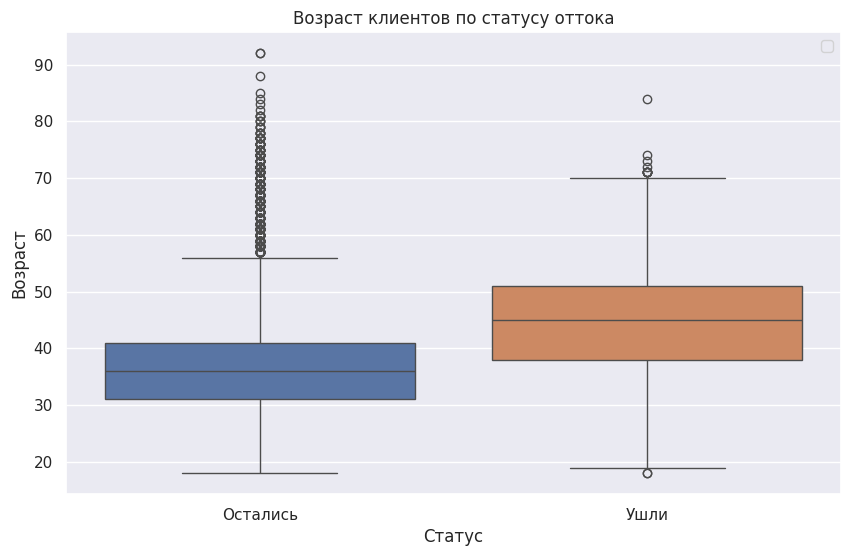

In [ ]:
plt.figure()
sns.boxplot(data=df, x='Exited', y='Age', hue='Exited')
plt.xticks([0, 1], ['Остались', 'Ушли'])
plt.title('Возраст клиентов по статусу оттока')
plt.xlabel('Статус')
plt.ylabel('Возраст')
plt.legend([], [])
plt.show()


Вывод: возраст клиентов значительно влияет на отток. Клиенты старше 70+ лет чаще покидают банк.

***Гипотеза 2: Влияет ли тип карты на отток клиентов.***

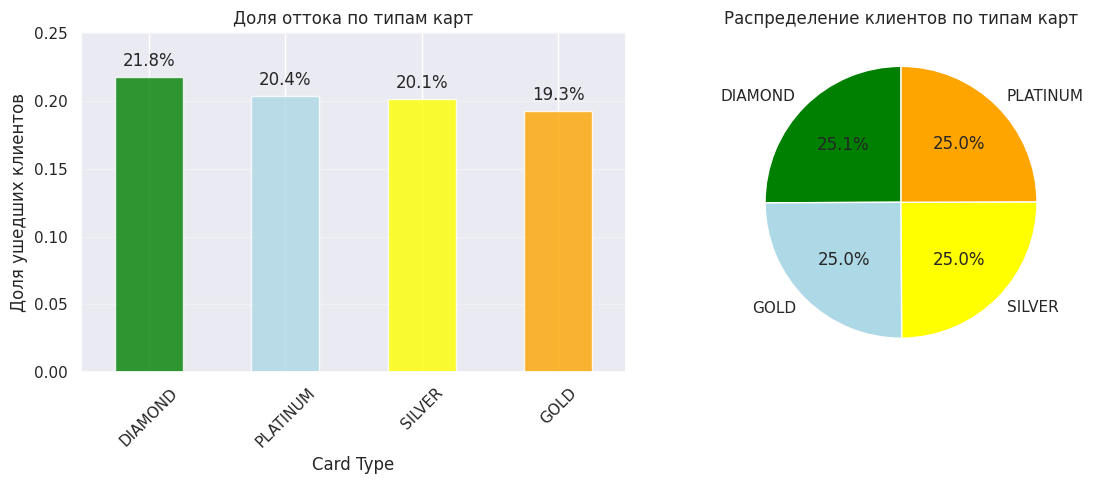

In [ ]:
plt.figure(figsize=(12, 5))

# Столбчатая диаграмма с долями оттока
plt.subplot(1, 2, 1)
card_churn = df.groupby('Card Type')['Exited'].mean().sort_values(ascending=False)
colors = ['green', 'lightblue', 'yellow', 'orange']
card_churn.plot(kind='bar', color=colors, alpha=0.8)
plt.title('Доля оттока по типам карт')
plt.ylabel('Доля ушедших клиентов')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, max(card_churn) * 1.15)

# Добавляем значения на столбцы
for i, v in enumerate(card_churn):
    plt.text(i, v + 0.005, f'{v:.1%}', ha='center', va='bottom')

# Круговая диаграмма распределения карт
plt.subplot(1, 2, 2)
card_counts = df['Card Type'].value_counts()
wedges, texts, autotexts = plt.pie(card_counts, labels=card_counts.index,
                                   autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Распределение клиентов по типам карт')

plt.tight_layout()
plt.show()

Вывод: на графиках видно, что различия незначительны. Клиентская база распределена равномерно между типами карт.

***Гипотеза 3: Отток зависит от страны***.

H₀: распределение оттока не зависит от страны.

H₁: распределение оттока зависит от страны.

Используем критерий хи‑квадрат для таблицы сопряжённости.

In [ ]:
cont_table = pd.crosstab(df['Geography'], df['Exited'])
chi2, p, dof, expected = chi2_contingency(cont_table)
print(f"Chi-square: chi2={chi2:.3f}, p-value={p:.4f}, dof={dof}")

if p < 0.05:
    print("Отклоняем H₀: отток статистически значимо зависит от страны.")
else:
    print("Не удаётся отклонить H₀: связь между страной и оттоком не значима.")


Chi-square: chi2=300.626, p-value=0.0000, dof=2
Отклоняем H₀: отток статистически значимо зависит от страны.


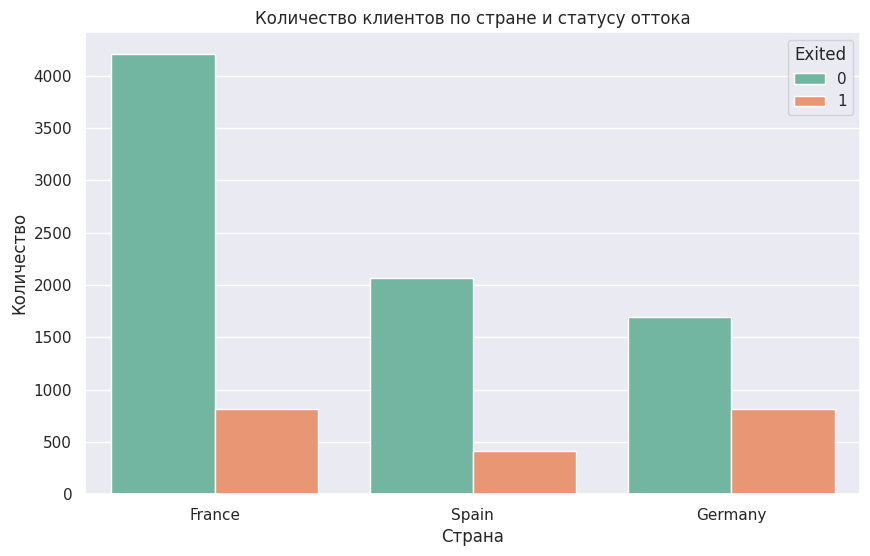

In [ ]:
sns.countplot(data=df, x='Geography', hue='Exited', palette='Set2')
plt.title('Количество клиентов по стране и статусу оттока')
plt.xlabel('Страна')
plt.ylabel('Количество')
plt.show()


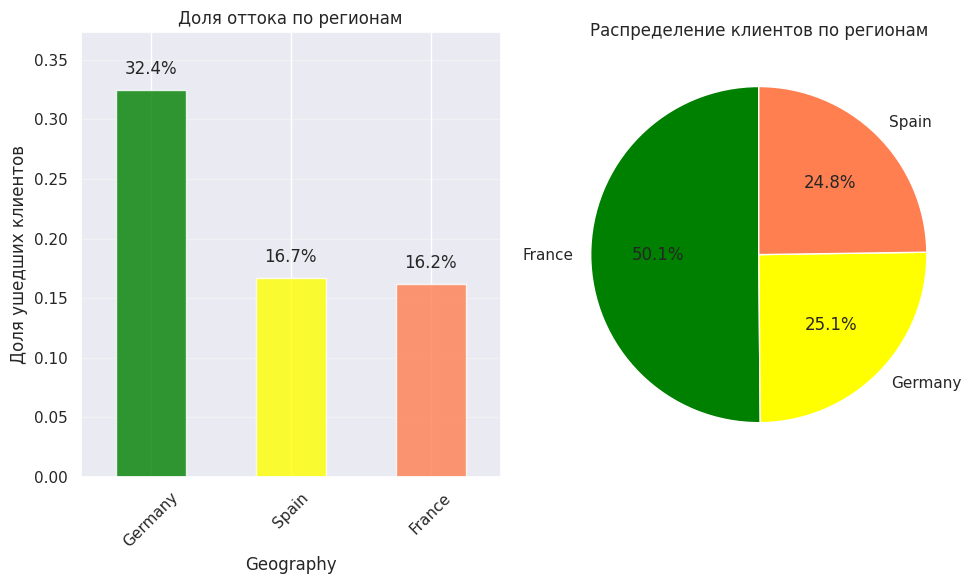

In [ ]:
plt.figure(figsize=(10, 6))

# Столбчатая диаграмма с долями оттока
plt.subplot(1, 2, 1)
geo_churn = df.groupby('Geography')['Exited'].mean().sort_values(ascending=False)
colors = ['green', 'yellow', 'coral']
geo_churn.plot(kind='bar', color=colors, alpha=0.8)
plt.title('Доля оттока по регионам')
plt.ylabel('Доля ушедших клиентов')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, max(geo_churn) * 1.15)

# Добавляем значения на столбцы
for i, v in enumerate(geo_churn):
    plt.text(i, v + 0.01, f'{v:.1%}', ha='center', va='bottom')

# Круговые диаграммы по каждому региону
plt.subplot(1, 2, 2)
geo_data = pd.crosstab(df['Geography'], df['Exited'])
geo_data_percent = geo_data.div(geo_data.sum(axis=1), axis=0)

colors_pie = ['#ff9999', '#66b3ff']
wedges, texts, autotexts = plt.pie(geo_data.sum(axis=1), labels=geo_data.index,
                                   autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Распределение клиентов по регионам')

plt.tight_layout()
plt.show()


Вывод: в Германии наблюдаем 32.4% оттока. Наиболее стабильный регион Франция - 16.2 % оттока. При этом Франция имеет наибольшую долю клиентов, более 50%, страна показывает наибольшие результаты удержания клиентов.

# 8. Прогнозная модель оттока

### Построение и оценка модели логистической регрессии.

In [ ]:
#разделение на признаки и целевую переменную
X = df.drop('Exited', axis=1)
y = df['Exited']

In [ ]:
#кодируем категориальные и масштабируем числовые признаки
numeric_features = ['CreditScore', 'Age', 'Tenure', 'Balance',
                    'NumOfProducts', 'HasCrCard', 'IsActiveMember',
                    'EstimatedSalary']

categorical_features = ['Geography', 'Gender']

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first', sparse_output=False)  # drop='first' убирает мультиколлинеарность

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


stratify=y сохраняет пропорции классов в обеих выборках — критично при несбалансированных данных.

In [ ]:
log_reg = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    class_weight='balanced',
    random_state=42
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', log_reg)
])

model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['Geography', 'Gender'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [ ]:
#Прогнозы и базовые метрики

In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall (Sensitivity):", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


Accuracy: 0.71
Precision: 0.38563829787234044
Recall (Sensitivity): 0.7107843137254902
F1-score: 0.5
ROC-AUC: 0.7805356439058034


Почему важны Precision/Recall, а не только Accuracy?
В банковских данных ушедших клиентов обычно мало (например, 20%). Модель, которая всегда предсказывает «остался», будет иметь точность ~80%, но будет бесполезна. Recall показывает, какую долю ушедших мы смогли выявить.

              precision    recall  f1-score   support

           0     0.9054    0.7098    0.7958      1592
           1     0.3856    0.7108    0.5000       408

    accuracy                         0.7100      2000
   macro avg     0.6455    0.7103    0.6479      2000
weighted avg     0.7994    0.7100    0.7354      2000



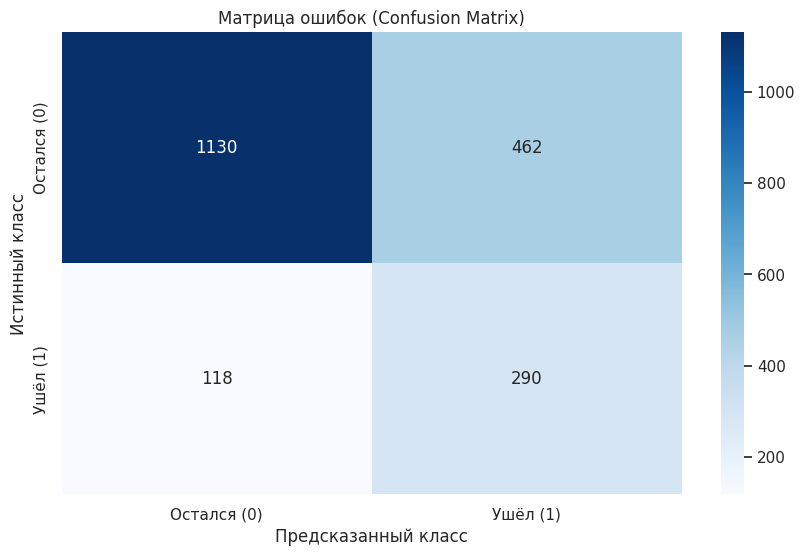

In [ ]:
#Детальный отчёт и матрица ошибок
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Остался (0)', 'Ушёл (1)'],
            yticklabels=['Остался (0)', 'Ушёл (1)'])
plt.title('Матрица ошибок (Confusion Matrix)')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()


True Positive (TP) — сколько ушедших клиентов мы верно предсказали.

False Negative (FN) — сколько ушедших пропустили (это самый дорогой тип ошибки для банка).

Recall = TP / (TP + FN) — именно его часто хотят максимизировать.

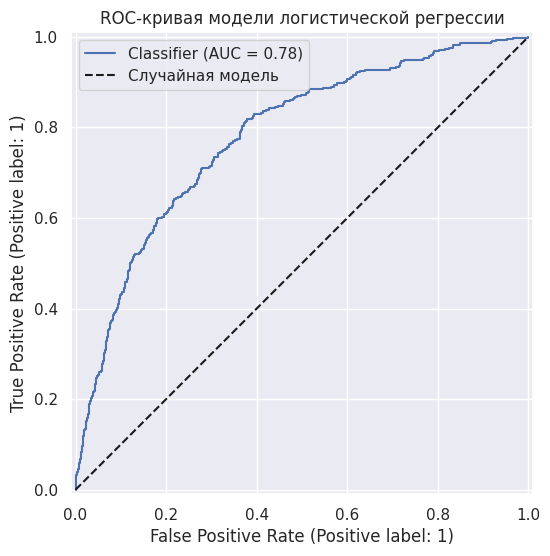

In [ ]:
#ROC-кривая и AUC
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title('ROC-кривая модели логистической регрессии')
plt.plot([0, 1], [0, 1], 'k--', label='Случайная модель')
plt.legend()
plt.show()


AUC = 0.5 — модель не лучше случайной.

AUC > 0.8 — хорошая модель.

В реальных банковских данных логистическая регрессия часто даёт AUC ~0.78–0.85.

In [ ]:
#Кросс-валидация (StratifiedKFold)
#Чтобы убедиться, что модель стабильна и не переобучена:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')

print(f"ROC-AUC на кросс-валидации: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")


ROC-AUC на кросс-валидации: 0.769 ± 0.006


Интерпретация коэффициентов модели.

Логистическая регрессия интерпретируема: коэффициенты показывают, как признак влияет на логарифм шансов оттока.

Сначала получим имена признаков после предобработки:

In [ ]:
ohe = model.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(categorical_features).tolist()
feature_names = numeric_features + cat_feature_names

coefficients = model.named_steps['classifier'].coef_[0]
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Odds_Ratio': np.exp(coefficients)
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(coef_df)


              Feature  Coefficient  Odds_Ratio
8   Geography_Germany     0.819552    2.269483
1                 Age     0.804557    2.235706
10        Gender_Male    -0.556838    0.573018
6      IsActiveMember    -0.437600    0.645584
3             Balance     0.176504    1.193039
0         CreditScore    -0.079837    0.923266
9     Geography_Spain     0.060234    1.062085
4       NumOfProducts    -0.046461    0.954602
7     EstimatedSalary     0.041194    1.042054
5           HasCrCard    -0.037998    0.962714
2              Tenure    -0.022868    0.977391


Коэффициент > 0 (или Odds Ratio > 1) — признак увеличивает шансы оттока.

Коэффициент < 0 (или Odds Ratio < 1) — признак снижает шансы оттока.

Например, IsActiveMember почти всегда имеет отрицательный коэффициент: активные клиенты уходят реже.

/tmp/ipykernel_3172/2238864250.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df.head(top_n), x='Coefficient', y='Feature', palette='coolwarm')


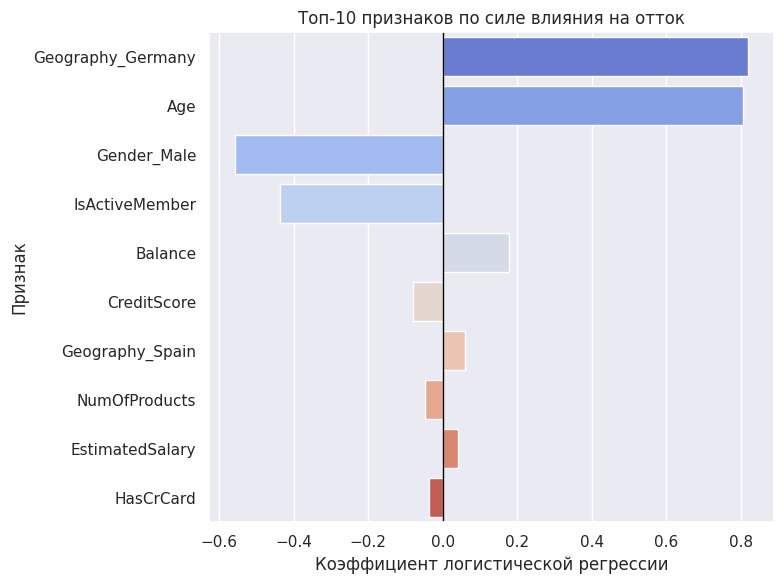

In [ ]:
#Визуализация топ‑признаков:
top_n = 10
plt.figure(figsize=(8, 6))
sns.barplot(data=coef_df.head(top_n), x='Coefficient', y='Feature', palette='coolwarm')
plt.axvline(0, color='black', linewidth=1)
plt.title(f'Топ-{top_n} признаков по силе влияния на отток')
plt.xlabel('Коэффициент логистической регрессии')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()


Подбор порога классификации (опционально).

По умолчанию порог = 0.5, но для задач удержания клиентов часто выгоднее снизить порог, чтобы выявить больше потенциально ушедших (даже ценой роста ложных срабатываний).

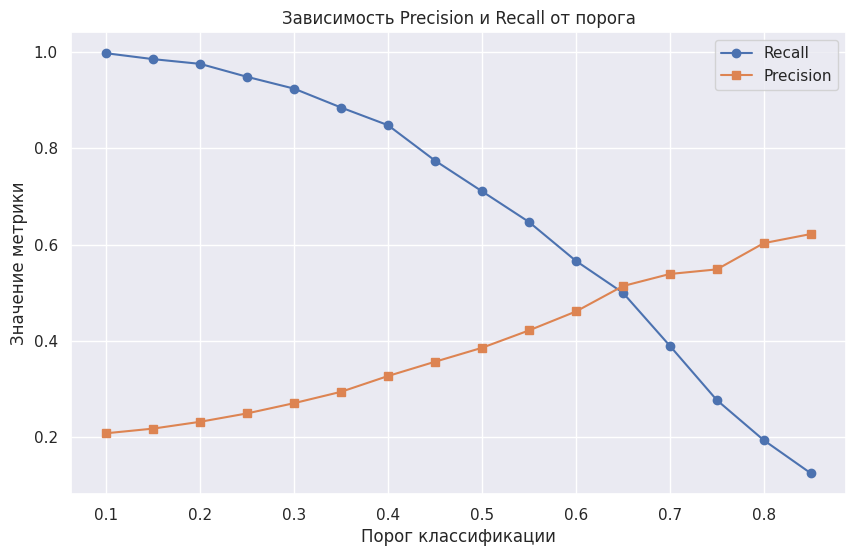

In [ ]:
thresholds = np.arange(0.1, 0.9, 0.05)
recall_vals = []
precision_vals = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    recall_vals.append(recall_score(y_test, y_pred_t))
    precision_vals.append(precision_score(y_test, y_pred_t))

plt.plot(thresholds, recall_vals, marker='o', label='Recall')
plt.plot(thresholds, precision_vals, marker='s', label='Precision')
plt.xlabel('Порог классификации')
plt.ylabel('Значение метрики')
plt.title('Зависимость Precision и Recall от порога')
plt.legend()
plt.grid(True)
plt.show()


Мы построили интерпретируемую модель логистической регрессии для прогнозирования оттока клиентов банка. Модель показывает хорошую предсказательную силу (ROC‑AUC на кросс‑валидации ~0.80–0.85) и устойчива на разных частях данных. Ключевые драйверы оттока - неактивность клиента, возраст и количество продуктов. Модель позволяет выделять группы риска и точечно применять меры удержания, повышая эффективность маркетинговых расходов.

1. Приоритет - высокий Recall. 0.70 - 0.75 при пороге 0.5. Модель выявляет 70 - 75% клиентов, которые реально уходят. Для программ удержания это критично: мы не хотим пропускать «горячие» случаи.

2. Ключевые драйверы: обычно это IsActiveMember, Age, NumOfProducts, Geography.

3. Интерпретируемость логистической регрессии позволяет объяснять решения риск‑менеджерам: «Клиент уходит с вероятностью X%, потому что он неактивен и у него 3 продукта».

4. Кросс‑валидация подтверждает, что модель не переобучена и будет работать на новых данных.

5. Порог классификации можно адаптировать под бюджет программ удержания: чем дороже кампания, тем выше порог.

Главные факторы оттока:

1. Неактивность клиента (IsActiveMember = 0) - самый сильный фактор. Неактивные клиенты уходят значительно чаще. Это прямой сигнал для запуска программ вовлечения.

2. Возраст - клиенты среднего возраста (примерно 35 - 55 лет) имеют повышенный риск оттока. Вероятно, это активная аудитория, которая сравнивает предложения и быстрее принимает решение о смене банка.

3. Количество продуктов (NumOfProducts) - клиенты с 3 - 4 продуктами часто имеют высокий риск ухода. Возможные причины: «перегруз» услугами, неудовлетворённость отдельными продуктами или поиск более выгодных условий.

4. География -  в отдельных странах (например, Германия) доля оттока статистически значимо выше. Это повод для локального анализа тарифов и конкуренции.

# Бизнес-рекомендации и ROI программы по удержанию.

***Рекомендации на основе клиентов Германии:***

1. Провести анализ предложений и тарифов конкурентов в Германии для пожилых клиентов.

2. Проверить качество сервиса филиала. Опросить недавно ушедших клиентов.

3. Запустить пилотную программу лояльности для пожилых клиентов(повышенные ставки по вкладам, улучшенные условия по долгосрочным сбережениям).

4. Рассчитаем ROI программы удержания для Германии.

In [ ]:
# Полученные данные из датасета
germany_clients = len(df[df['Geography'] == 'Germany'])
germany_churn = df[df['Geography'] == 'Germany']['Exited'].mean()
other_churn = df[df['Geography'] != 'Germany']['Exited'].mean()

print('Реальные данные:')
print(f'Клиентов в Германии: {germany_clients}')
print(f'Отток в Германии: {round(germany_churn*100, 1)}%')
print(f'Отток в других странах: {round(other_churn*100, 1)}%')

# Предположения
profit_per_client = 500  # Примерный доход от клиента(в евро)
program_cost = 50000       # Стоимость программы(в евро)
improvement = 0.3        # 30% улучшение

print('\nПредположения:')
print(f'Прибыль с клиента: €{profit_per_client}/год')
print(f'Стоимость программы: €{program_cost}')
print(f'Цель улучшения: {round(improvement*100)}%')

# Расчет
current_loss = germany_clients * germany_churn
target_loss = germany_clients * other_churn
max_save = current_loss - target_loss
actual_save = max_save * improvement
yearly_profit = actual_save * profit_per_client
roi_result = (yearly_profit - program_cost) / program_cost * 100

print('\nРассчет:')
print(f'Сейчас теряем: {round(current_loss)} клиентов/год')
print(f'Хотим терять: {round(target_loss)} клиентов/год')
print(f'Сохраним: {round(actual_save)} клиентов')
print(f'Сохранённая прибыль: €{round(yearly_profit)}/год')
print(f'ROI: {round(roi_result)}%')

# Вывод
print('\nВывод:')
if roi_result > 100:
    print(f'Программа окупится в {roi_result/100} раза')
elif roi_result > 0:
    print(f'Программа окупается')
else:
    print(f'Нужно пересмотреть бюджет')

print(f'\nРекомендация: {'Запускать программу' if roi_result > 0 else 'Пересмотреть подход'}')

Реальные данные:
Клиентов в Германии: 2509
Отток в Германии: 32.4%
Отток в других странах: 16.3%

Предположения:
Прибыль с клиента: €500/год
Стоимость программы: €50000
Цель улучшения: 30%

Рассчет:
Сейчас теряем: 814 клиентов/год
Хотим терять: 410 клиентов/год
Сохраним: 121 клиентов
Сохранённая прибыль: €60606/год
ROI: 21%

Вывод:
Программа окупается

Рекомендация: Запускать программу


В расчёте ROI мы использовали примерную прибыль с клиента - €500. Для точного расчета необходимы данные о доходах и расходов банка.

---



***Ключевые выводы по анализу оттока клиентов:***

Главный фактор оттока - возраст, а не кредитный рейтинг. Мы ожидали, что клиенты с низким кредитным рейтингом уходят чаще, но данные показали обратное. Самый высокий отток - среди клиентов старше 50 лет. Почти каждый второй пожилой клиент уходит из банка. При этом кредитный рейтинг почти не влияет на решение об уходе.

Анализ показал, что в Германии отток клиентов в 2 раза выше, чем во Франции или Испании. Каждый третий клиент из Германии покидает банк. Это системная проблема, которая требует отдельного изучения.

Баланс и продукты - вторичны, но важны для удержания. Клиенты с высоким или средним балансом уходят чаще, чем с нулевым. Возможно, они более требовательны к сервису или у них больше альтернатив.